Dhanush Sambasivam ( 121331816 )

Madhumitha Rajagopal ( 121331472 )

In [1]:
# Preprocessing for HMM Market Regime Detection (SPY)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load data and sort
df = pd.read_csv("/content/SPY_10y_raw.csv", parse_dates=["Date"])
df.sort_values("Date", inplace=True)
df.reset_index(drop=True, inplace=True)

In [3]:
# Select and rename necessary columns
df = df[["Date", "close", "returns", "volatility", "rsi"]].copy()
df.rename(columns={"close": "Close", "returns": "Return",
                   "volatility": "Volatility", "rsi": "RSI"}, inplace=True)

In [4]:
# Return binning into tertiles
df["Return_Bin"] = pd.qcut(df["Return"], q=3, labels=["Low", "Medium", "High"])

In [5]:
# Volatility binning using median
median_vol = df["Volatility"].median()
df["Vol_Bin"] = np.where(df["Volatility"] > median_vol, "High", "Low")

In [6]:
# RSI signal labeling
def rsi_label(val):
    if val > 70:
        return "Overbought"
    elif val < 30:
        return "Oversold"
    else:
        return "Neutral"

df["RSI_Signal"] = df["RSI"].apply(rsi_label)

# Create observation tuple
df["Observation"] = list(zip(df["Return_Bin"], df["Vol_Bin"], df["RSI_Signal"]))

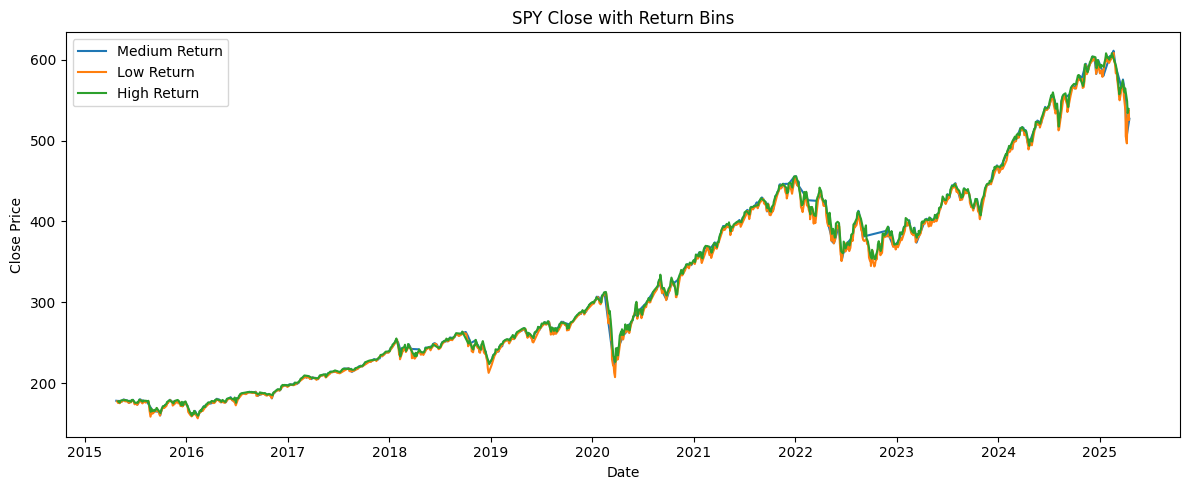

In [13]:
# Plot SPY Close price with Return Bins
plt.figure(figsize=(12, 5))
for label in df["Return_Bin"].unique():
    mask = df["Return_Bin"] == label
    plt.plot(df["Date"][mask], df["Close"][mask], label=f"{label} Return")
plt.title("SPY Close with Return Bins")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.tight_layout()
plt.show()

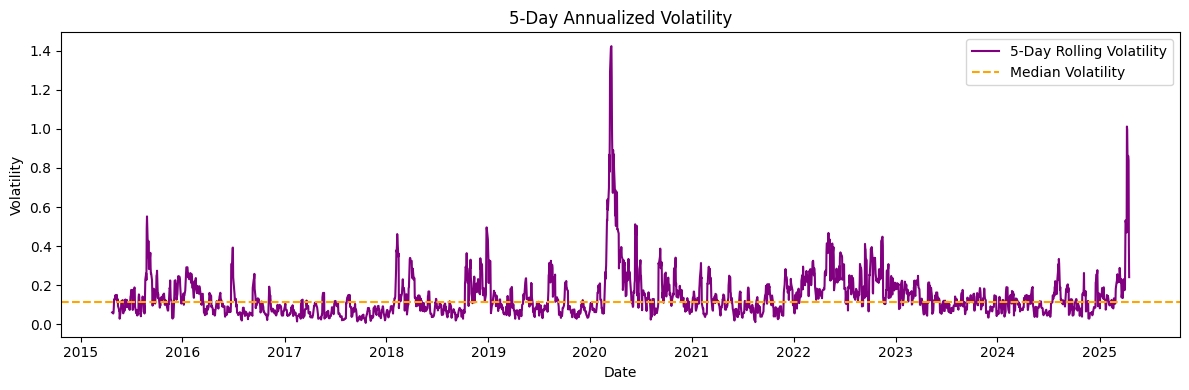

In [11]:
# Plot 5-Day Rolling Volatility (Annualized)
plt.figure(figsize=(12, 4))
plt.plot(df["Date"], df["Volatility"], label="5-Day Rolling Volatility", color="purple")
plt.axhline(median_vol, color='orange', linestyle='--', label="Median Volatility")
plt.title("5-Day Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.tight_layout()
plt.show()

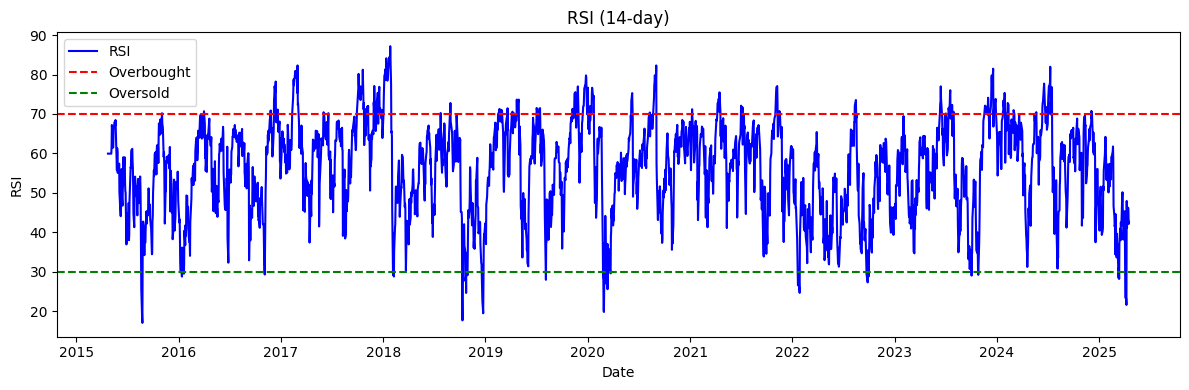

In [8]:
# Plot RSI with thresholds
plt.figure(figsize=(12, 4))
plt.plot(df["Date"], df["RSI"], label="RSI", color="blue")
plt.axhline(70, color='red', linestyle='--', label="Overbought")
plt.axhline(30, color='green', linestyle='--', label="Oversold")
plt.title("RSI (14-day)")
plt.xlabel("Date")
plt.ylabel("RSI")
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# Final dataframe
final_df = df[["Date", "Close", "Return", "Volatility", "RSI",
               "Return_Bin", "Vol_Bin", "RSI_Signal", "Observation"]]

In [10]:
# Optional: Save to CSV for HMM use
final_df.to_csv("SPY_preprocessed.csv", index=False)